In [1]:
source("/mnt/users/rachelsavage/paper_minimorf/code/figure_code/Figure_Code_Presets.r")
library(arrow)
library(igraph)
library(ggraph)



Attaching package: ‘arrow’


The following object is masked from ‘package:BiocGenerics’:

    type


The following object is masked from ‘package:utils’:

    timestamp



Attaching package: ‘igraph’


The following object is masked from ‘package:circlize’:

    degree


The following object is masked from ‘package:tibble’:

    as_data_frame


The following object is masked from ‘package:tidyr’:

    crossing


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following object is masked from ‘package:GenomicRanges’:

    union


The following object is masked from ‘package:IRanges’:

    union


The following object is masked from ‘package:S4Vectors’:

    union


The following objects are masked from ‘package:BiocGenerics’:

    normalize, path, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




# prep

In [5]:
# note: 0-9 are the 500k version. 10-19 are the tf barcodes version

In [3]:
all.mxs <- lapply(0:19, function(x){
    file <- paste0("/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna.raw.filt/", x, "/topic100/topic100_region_topics_binarized.feather")
    f1 <- read_feather(file)
    f1 <- f1 %>% column_to_rownames("region")%>% as.matrix()
    colnames(f1) <- paste0(colnames(f1), "_", x)
    return(f1)
})
all.mxs <- do.call(cbind, all.mxs)

In [14]:
all.mxs <- all.mxs[,colSums(all.mxs)>= 20]

In [18]:
all.mxs <- all.mxs[,colSums(all.mxs)<= 500]

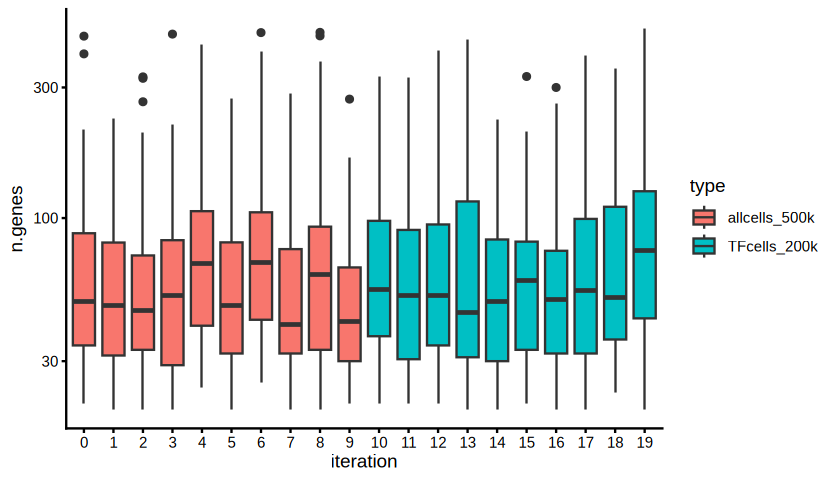

In [19]:
options(repr.plot.width = 7, repr.plot.height = 4)

topic.size.df <- data.frame(n.peaks = colSums(all.mxs)) %>%
rownames_to_column("topic")%>%
mutate(iteration = as.numeric(stri_split_fixed(topic, pattern = "_", simplify = TRUE)[,2]),
       type = ifelse(iteration<= 9, "allcells_500k", "TFcells_200k")) %>%
arrange(iteration) %>%
mutate(iteration = factor(iteration, levels = unique(iteration)))

topic.size.df %>%
ggplot(aes(x=iteration, y=n.peaks, fill = type))+
geom_boxplot()+
theme_classic()+
scale_y_continuous(trans = "log10")+
ylab("n.genes")

In [20]:
s <- colSums(all.mxs)
inter <- crossprod(all.mxs)
union <- outer(s, s, "+") - inter
jac_sim  <- inter / union

###one thing to consider is that we should divide by the smallest member? 

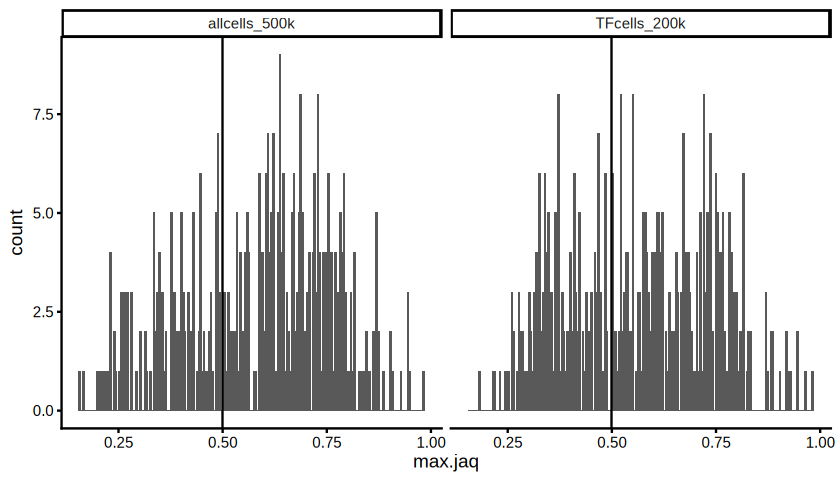

In [23]:
graph.mx <- jac_sim
diag(graph.mx) <- 0

max.df <- data.frame(max.jaq = colMaxs(graph.mx)) %>%
rownames_to_column("topic") %>%
mutate(iteration = as.numeric(stri_split_fixed(topic, pattern = "_", simplify = TRUE)[,2]),
       type = ifelse(iteration<= 9, "allcells_500k", "TFcells_200k"))


options(repr.plot.width = 7, repr.plot.height = 4)

cutoff <- 0.5

max.df %>%
ggplot(aes(x=max.jaq))+
geom_histogram(bins = 200)+
theme_classic()+
geom_vline(xintercept = cutoff)+
facet_wrap(~type)


In [24]:
graph.mx.filt <- graph.mx[colMaxs(graph.mx)>cutoff, colMaxs(graph.mx)>cutoff]
dim(graph.mx.filt)

[1] 534 534

In [31]:
cutoff2 <- 0.6 #0.4 looked good
adj <- graph.mx.filt >= cutoff2
diag(adj) <- FALSE
adj <- adj | t(adj)
set.seed(123)
g <- graph_from_adjacency_matrix(adj, mode = "undirected", diag = FALSE)
g <- delete_vertices(g, V(g)[degree(g) == 0])
#clusters <- components(g)$membership
set.seed(123)
lay <- create_layout(g, layout = "fr")
comps <- components(g)

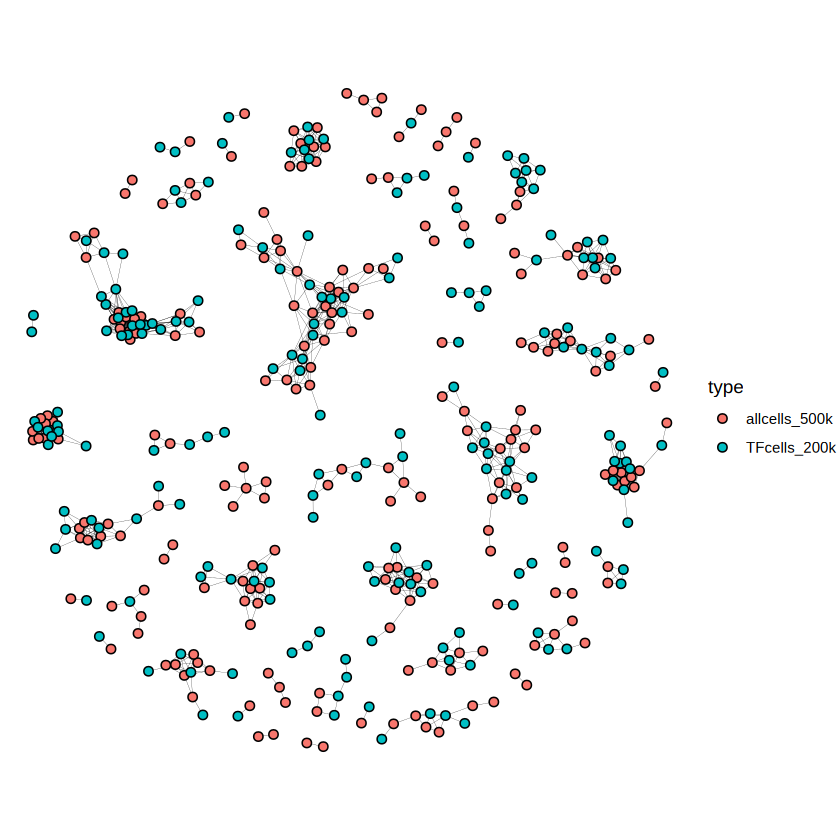

In [32]:
node.df <- as.data.frame(lay) %>%
mutate(iteration = as.numeric(stri_split_fixed(name, pattern = "_", simplify = TRUE)[,2]),
       type = ifelse(iteration<= 9, "allcells_500k", "TFcells_200k"))

node.df$cluster <- components(g)$membership
node.df$degree <- degree(g)
node.df<- node.df%>%
  mutate(
    comp_id = comps$membership[name],
    cluster_size = comps$csize[comp_id]
  ) %>%
mutate(deg_cat = case_when(
    (degree == 1 & cluster_size == 2) ~ "1 keep",
    degree == 1 ~ "1",
    degree >= 2 ~ "2+"
  )) 

node.df.from <- node.df
colnames(node.df.from) <- paste0(colnames(node.df.from), "_from")

node.df.to <- node.df
colnames(node.df.to) <- paste0(colnames(node.df.to), "_to")

edge.df <- igraph::as_data_frame(g, what = "edges")  %>% 
    left_join(node.df.from, by = c("from" = "name_from")) %>%
    left_join(node.df.to, by = c("to" = "name_to")) 
options(repr.plot.width = 7, repr.plot.height = 7)

ggplot()+
geom_segment(data = edge.df, 
             (aes(x=x_from, xend = x_to, 
                                  y= y_from, yend = y_to)), #, color = as.factor(cluster_id_from))), 
             show.legend = FALSE, 
            linewidth = 0.05,
            color = "black")+
geom_point(data = node.df, aes(x=x, y=y, fill = type), color = "black", shape = 21,
           size = 2)+
theme_void()+
coord_fixed()

# so it looks like TF-only isn't providing many unique clusters. 


In [22]:
all.mxs <- lapply(0:9, function(x){
    file <- paste0("/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna.raw.filt/", x, "/topic100/topic100_region_topics_binarized.feather")
    f1 <- read_feather(file)
    f1 <- f1 %>% column_to_rownames("region")%>% as.matrix()
    colnames(f1) <- paste0(colnames(f1), "_", x)
    return(f1)
})
all.mxs <- do.call(cbind, all.mxs)
all.mxs <- all.mxs[,colSums(all.mxs)>= 20]
all.mxs <- all.mxs[,colSums(all.mxs)<= 500]

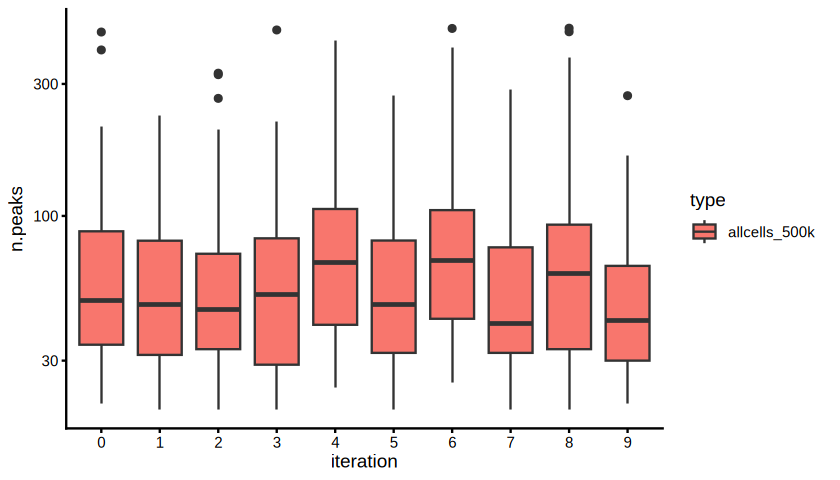

In [3]:
options(repr.plot.width = 7, repr.plot.height = 4)

topic.size.df <- data.frame(n.peaks = colSums(all.mxs)) %>%
rownames_to_column("topic")%>%
mutate(iteration = as.numeric(stri_split_fixed(topic, pattern = "_", simplify = TRUE)[,2]),
       type = ifelse(iteration<= 9, "allcells_500k", "TFcells_200k")) %>%
arrange(iteration) %>%
mutate(iteration = factor(iteration, levels = unique(iteration)))

topic.size.df %>%
ggplot(aes(x=iteration, y=n.peaks, fill = type))+
geom_boxplot()+
theme_classic()+
scale_y_continuous(trans = "log10")

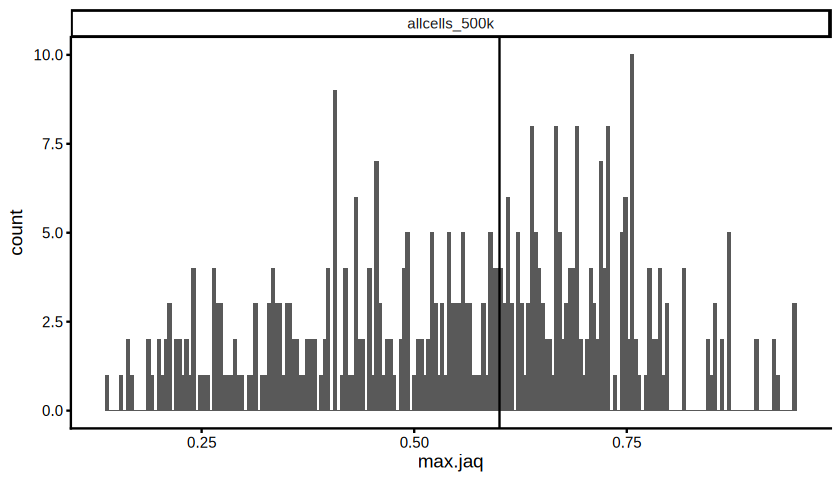

In [4]:
s <- colSums(all.mxs)
inter <- crossprod(all.mxs)
union <- outer(s, s, "+") - inter
jac_sim  <- inter / union

graph.mx <- jac_sim
diag(graph.mx) <- 0

max.df <- data.frame(max.jaq = colMaxs(graph.mx)) %>%
rownames_to_column("topic") %>%
mutate(iteration = as.numeric(stri_split_fixed(topic, pattern = "_", simplify = TRUE)[,2]),
       type = ifelse(iteration<= 9, "allcells_500k", "TFcells_200k"))


options(repr.plot.width = 7, repr.plot.height = 4)

cutoff <- 0.6

max.df %>%
ggplot(aes(x=max.jaq))+
geom_histogram(bins = 200)+
theme_classic()+
geom_vline(xintercept = cutoff)+
facet_wrap(~type)


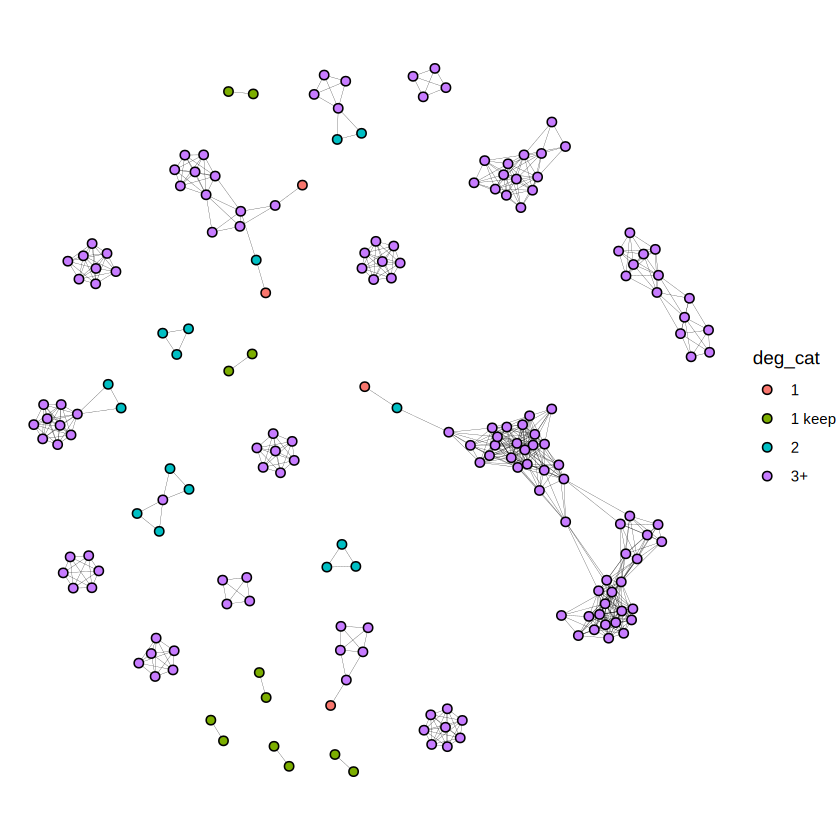

In [5]:
graph.mx.filt <- graph.mx[colMaxs(graph.mx)>cutoff, colMaxs(graph.mx)>cutoff]

cutoff2 <- 0.4 #0.4 looked good
adj <- graph.mx.filt >= cutoff2
diag(adj) <- FALSE
adj <- adj | t(adj)
set.seed(123)
g <- graph_from_adjacency_matrix(adj, mode = "undirected", diag = FALSE)
g <- delete_vertices(g, V(g)[degree(g) == 0])
#clusters <- components(g)$membership
set.seed(123)
lay <- create_layout(g, layout = "fr")
comps <- components(g)

node.df <- as.data.frame(lay) %>%
mutate(iteration = as.numeric(stri_split_fixed(name, pattern = "_", simplify = TRUE)[,2]),
       type = ifelse(iteration<= 9, "allcells_500k", "TFcells_200k"))

node.df$cluster <- components(g)$membership
node.df$degree <- degree(g)
node.df<- node.df%>%
  mutate(
    comp_id = comps$membership[name],
    cluster_size = comps$csize[comp_id]
  ) %>%
mutate(deg_cat = case_when(
    (degree == 1 & cluster_size <= 3) ~ "1 keep",
    degree == 1 ~ "1",
    degree == 2 ~ "2",
    degree > 2 ~ "3+"
  )) 

node.df.from <- node.df
colnames(node.df.from) <- paste0(colnames(node.df.from), "_from")

node.df.to <- node.df
colnames(node.df.to) <- paste0(colnames(node.df.to), "_to")

edge.df <- igraph::as_data_frame(g, what = "edges")  %>% 
    left_join(node.df.from, by = c("from" = "name_from")) %>%
    left_join(node.df.to, by = c("to" = "name_to")) 

options(repr.plot.width = 7, repr.plot.height = 7)

ggplot()+
geom_segment(data = edge.df, 
             (aes(x=x_from, xend = x_to, 
                                  y= y_from, yend = y_to)), #, color = as.factor(cluster_id_from))), 
             show.legend = FALSE, 
            linewidth = 0.05,
            color = "black")+
geom_point(data = node.df, aes(x=x, y=y, fill = deg_cat), color = "black", shape = 21,
           size = 2)+
theme_void()+
coord_fixed()

## filter nodes with 1 connection (that also aren't a member of two-member clusters)

In [6]:
topics.to.keep <- (node.df) %>%
filter(cluster_size>3) %>% 
filter(degree>1)%>%pull(name)

adj <- graph.mx.filt >= cutoff2
diag(adj) <- FALSE
adj <- adj | t(adj)
set.seed(123)
adj.filt <- adj[topics.to.keep,topics.to.keep]
g <- graph_from_adjacency_matrix(adj.filt, mode = "undirected", diag = FALSE)
g <- delete_vertices(g, V(g)[degree(g) == 0])
set.seed(123)
lay <- create_layout(g, layout = "fr")
comps <- components(g)
node.df <- as.data.frame(lay) %>%
mutate(iteration = as.numeric(stri_split_fixed(name, pattern = "_", simplify = TRUE)[,2]))
node.df$cluster <- components(g)$membership
node.df$degree <- degree(g)
node.df<- node.df%>%
  mutate(
    comp_id = comps$membership[name],
    cluster_size = comps$csize[comp_id]
  ) %>%
mutate(deg_cat = case_when(
    (degree == 1 & cluster_size <= 3) ~ "1 keep",
    degree == 1 ~ "1",
    degree >= 2 ~ "2+"
  )) 

node.df.from <- node.df
colnames(node.df.from) <- paste0(colnames(node.df.from), "_from")

node.df.to <- node.df
colnames(node.df.to) <- paste0(colnames(node.df.to), "_to")

edge.df <- igraph::as_data_frame(g, what = "edges")  %>% 
    left_join(node.df.from, by = c("from" = "name_from")) %>%
    left_join(node.df.to, by = c("to" = "name_to")) 


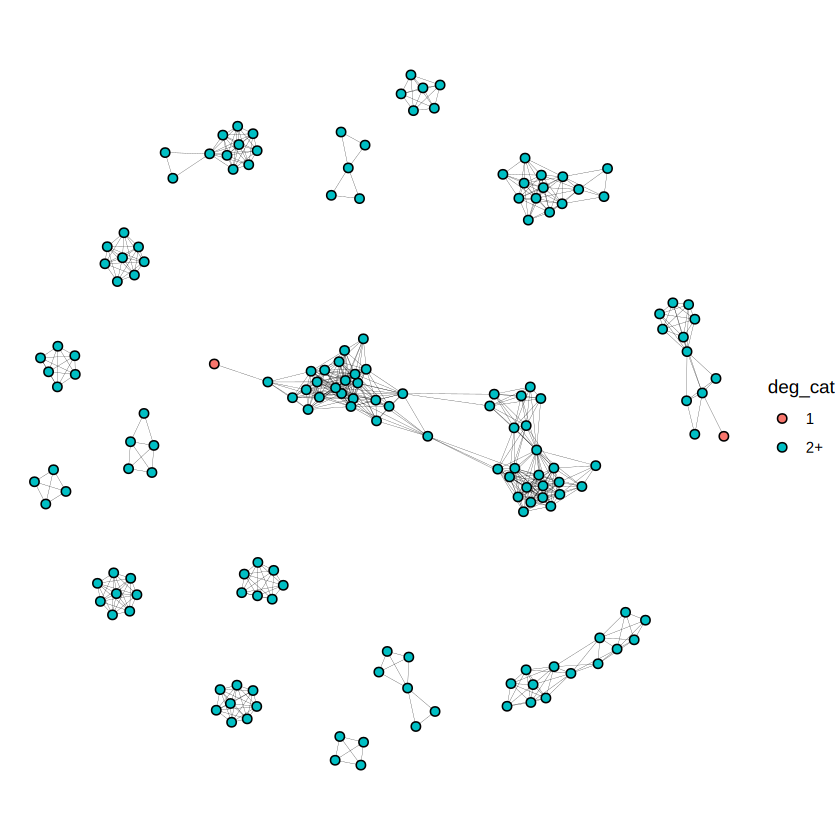

In [7]:
options(repr.plot.width = 7, repr.plot.height = 7)

ggplot()+
geom_segment(data = edge.df, 
             (aes(x=x_from, xend = x_to, 
                                  y= y_from, yend = y_to)), #, color = as.factor(cluster_id_from))), 
             show.legend = FALSE, 
            linewidth = 0.05,
            color = "black")+
geom_point(data = node.df, aes(x=x, y=y, fill = deg_cat), color = "black", shape = 21,
           size = 2)+
theme_void()+
coord_fixed()


# once more

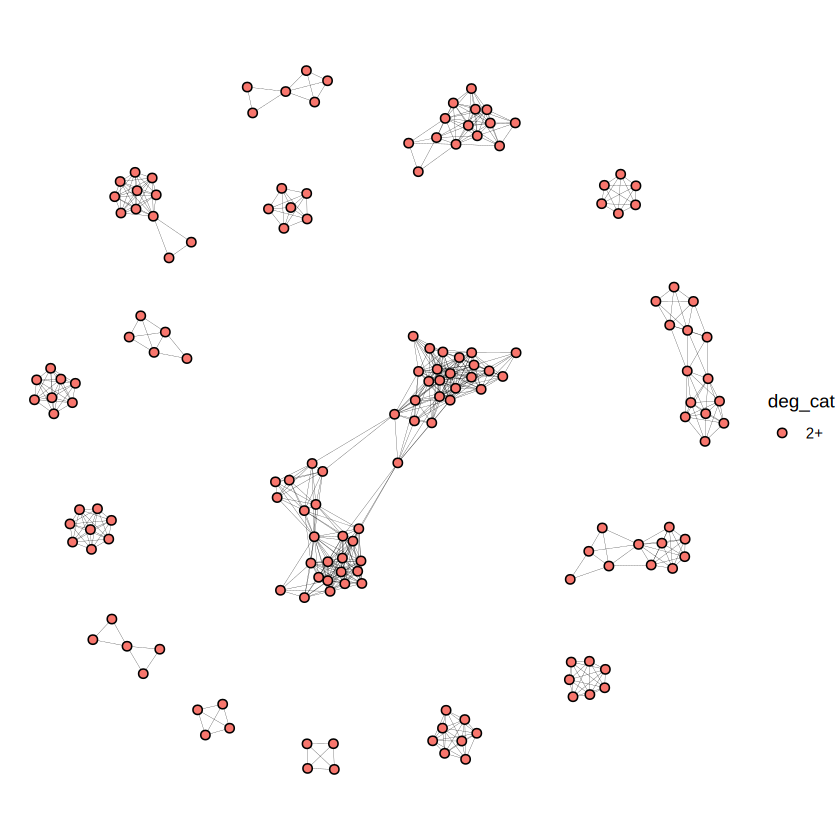

In [8]:
topics.to.keep <- (node.df) %>%
filter(cluster_size>3) %>% 
filter(degree>1)%>%pull(name)

adj <- graph.mx.filt >= cutoff2
diag(adj) <- FALSE
adj <- adj | t(adj)
set.seed(123)
adj.filt <- adj[topics.to.keep,topics.to.keep]
g <- graph_from_adjacency_matrix(adj.filt, mode = "undirected", diag = FALSE)
g <- delete_vertices(g, V(g)[degree(g) == 0])
set.seed(123)
lay <- create_layout(g, layout = "fr")
comps <- components(g)
node.df <- as.data.frame(lay) %>%
mutate(iteration = as.numeric(stri_split_fixed(name, pattern = "_", simplify = TRUE)[,2]))
node.df$cluster <- components(g)$membership
node.df$degree <- degree(g)
node.df<- node.df%>%
  mutate(
    comp_id = comps$membership[name],
    cluster_size = comps$csize[comp_id]
  ) %>%
mutate(deg_cat = case_when(
    (degree == 1 & cluster_size <= 3) ~ "1 keep",
    degree == 1 ~ "1",
    degree >= 2 ~ "2+"
  )) 

node.df.from <- node.df
colnames(node.df.from) <- paste0(colnames(node.df.from), "_from")

node.df.to <- node.df
colnames(node.df.to) <- paste0(colnames(node.df.to), "_to")

edge.df <- igraph::as_data_frame(g, what = "edges")  %>% 
    left_join(node.df.from, by = c("from" = "name_from")) %>%
    left_join(node.df.to, by = c("to" = "name_to")) 

options(repr.plot.width = 7, repr.plot.height = 7)

ggplot()+
geom_segment(data = edge.df, 
             (aes(x=x_from, xend = x_to, 
                                  y= y_from, yend = y_to)), #, color = as.factor(cluster_id_from))), 
             show.legend = FALSE, 
            linewidth = 0.05,
            color = "black")+
geom_point(data = node.df, aes(x=x, y=y, fill = deg_cat), color = "black", shape = 21,
           size = 2)+
theme_void()+
coord_fixed()


# break up too big clusters

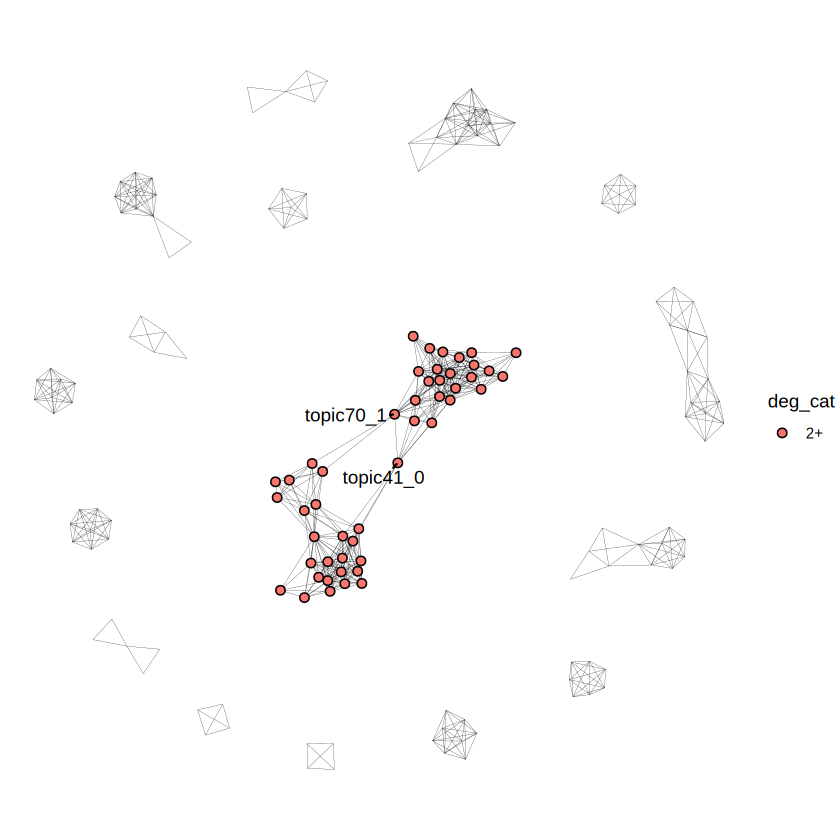

In [9]:
asdf <- node.df %>%
filter(cluster ==3)  %>%
mutate(label = ifelse(name %in% c("topic41_0", "topic70_1"), name, ""))


ggplot()+
geom_segment(data = edge.df, 
             (aes(x=x_from, xend = x_to, 
                                  y= y_from, yend = y_to)), #, color = as.factor(cluster_id_from))), 
             show.legend = FALSE, 
            linewidth = 0.05,
            color = "black")+
geom_point(data = asdf, aes(x=x, y=y, fill = deg_cat), color = "black", shape = 21,
           size = 2)+
geom_text_repel(data = asdf, aes(x=x, y=y, label = label), min.segment.length = 0)+
theme_void()+
coord_fixed()

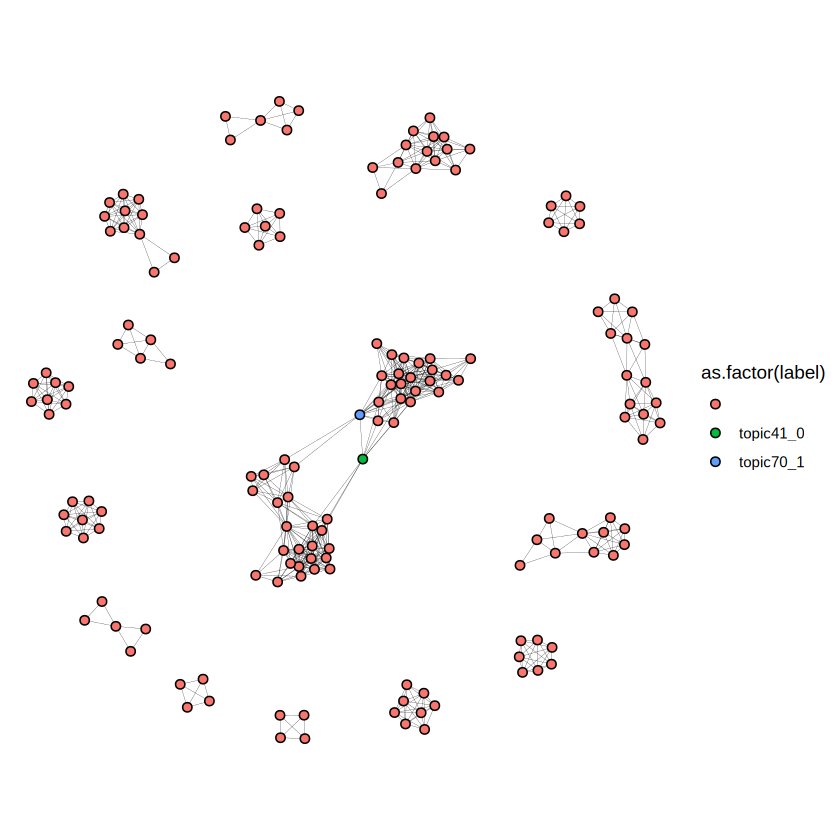

In [10]:
node.df.2 <- node.df %>%
mutate(label = ifelse(name %in% c("topic41_0", "topic70_1"), name, "")) 

options(repr.plot.width = 7, repr.plot.height = 7)

ggplot()+
geom_segment(data = edge.df, 
             (aes(x=x_from, xend = x_to, 
                                  y= y_from, yend = y_to)), #, color = as.factor(cluster_id_from))), 
             show.legend = FALSE, 
            linewidth = 0.05,
            color = "black")+
geom_point(data = node.df.2, aes(x=x, y=y, fill = as.factor(label)), color = "black", shape = 21,
           size = 2)+
theme_void()+
coord_fixed()

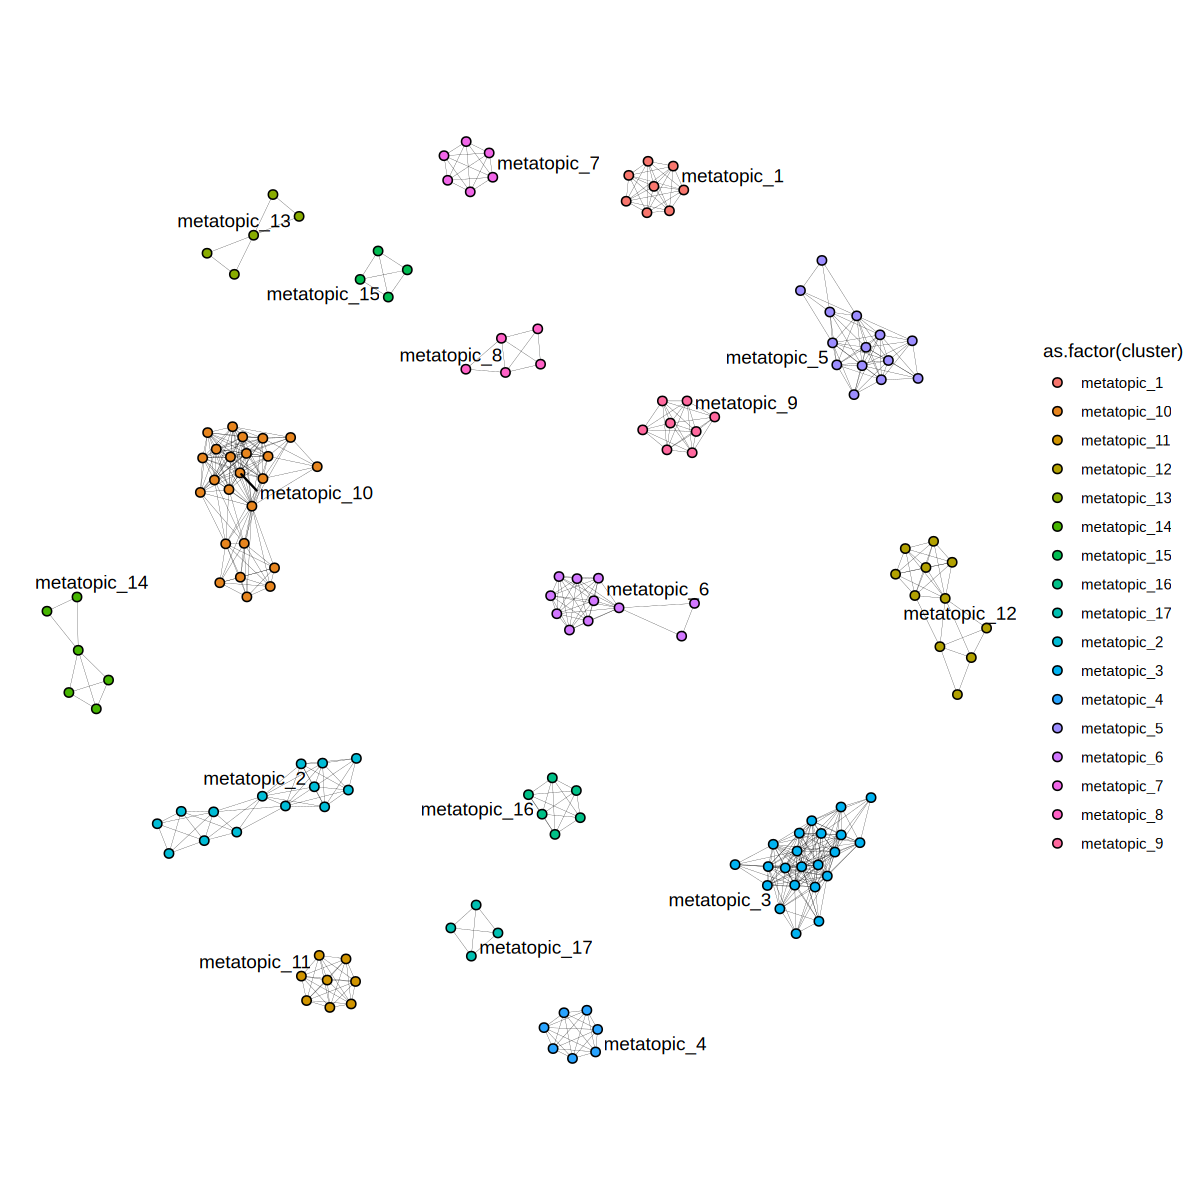

In [11]:
topics.to.keep <- node.df.2 %>%
filter(label == "")  %>% pull(name)

adj <- graph.mx.filt >= cutoff2
diag(adj) <- FALSE
adj <- adj | t(adj)
set.seed(123)
adj.filt <- adj[topics.to.keep,topics.to.keep]
g <- graph_from_adjacency_matrix(adj.filt, mode = "undirected", diag = FALSE)
g <- delete_vertices(g, V(g)[degree(g) == 0])
set.seed(123)
lay <- create_layout(g, layout = "fr")
comps <- components(g)
node.df <- as.data.frame(lay) %>%
mutate(iteration = as.numeric(stri_split_fixed(name, pattern = "_", simplify = TRUE)[,2]))
node.df$cluster <- components(g)$membership
node.df$degree <- degree(g)
node.df<- node.df%>%
  mutate(
    comp_id = comps$membership[name],
    cluster_size = comps$csize[comp_id]
  ) %>%
mutate(deg_cat = case_when(
    (degree == 1 & cluster_size == 2) ~ "1 keep",
    degree == 1 ~ "1",
    degree >= 2 ~ "2+"
  ))  %>%
mutate(cluster = paste0("metatopic_", cluster)) %>%
group_by(cluster)%>%
  mutate(label = if_else(row_number() == 1, cluster, "")) %>%
  ungroup()


node.df.from <- node.df
colnames(node.df.from) <- paste0(colnames(node.df.from), "_from")

node.df.to <- node.df
colnames(node.df.to) <- paste0(colnames(node.df.to), "_to")

edge.df <- igraph::as_data_frame(g, what = "edges")  %>% 
    left_join(node.df.from, by = c("from" = "name_from")) %>%
    left_join(node.df.to, by = c("to" = "name_to")) 

options(repr.plot.width = 10, repr.plot.height = 10)

ggplot()+
geom_segment(data = edge.df, 
             (aes(x=x_from, xend = x_to, 
                                  y= y_from, yend = y_to)), #, color = as.factor(cluster_id_from))), 
             show.legend = FALSE, 
            linewidth = 0.05,
            color = "black")+
geom_point(data = node.df, aes(x=x, y=y, fill = as.factor(cluster)), color = "black", shape = 21,
           size = 2)+
geom_text_repel(data = node.df, aes(x=x, y=y, label = label))+
theme_void()+
coord_fixed()


# save graph stuff

In [12]:
saveRDS(edge.df, "/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna.edge.df.rds")
saveRDS(node.df, "/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna.node.df.rds")

In [2]:
edge.df <- readRDS("/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna.edge.df.rds")
node.df <- readRDS("/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna.node.df.rds")

# extract topic clusters

In [3]:
all.mxs.notbinary <- lapply(0:9, function(x){
    file <- paste0("/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna.raw.filt/", x, "/topic100/topic100_region_topics.feather")
    f1 <- read_feather(file)
    f1 <- f1 %>% column_to_rownames("region")%>% as.matrix()
    colnames(f1) <- paste0(colnames(f1), "_", x)
    return(f1)
})
all.mxs.notbinary <- do.call(cbind, all.mxs.notbinary)

In [5]:
cluster.topic.mx <- sapply(
  split(cluster.df$name, cluster.df$cluster),
  \(x) rowMeans(all.mxs.notbinary[, x, drop = FALSE])
)

In [70]:
cluster.topic.mx.df <- as.data.frame(cluster.topic.mx) %>% rownames_to_column("peak")
fwrite(cluster.topic.mx.df, "/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna_metatopics.meantopic.txt")

# same groupings, but get "leader topic" instead of mean

In [71]:
cluster.df.2 <- node.df %>% dplyr::select(name, cluster, degree) %>%
group_by(cluster)%>%
arrange(-degree)%>%
slice_head(n=1) %>%
mutate(rename = paste0(cluster, "_", name))
head(cluster.df.2)

name,cluster,degree,rename
<chr>,<chr>,<dbl>,<chr>
topic1_0,metatopic_1,7,metatopic_1_topic1_0
topic38_2,metatopic_10,22,metatopic_10_topic38_2
topic66_0,metatopic_11,7,metatopic_11_topic66_0
topic88_0,metatopic_12,9,metatopic_12_topic88_0
topic10_1,metatopic_13,4,metatopic_13_topic10_1
topic73_7,metatopic_14,5,metatopic_14_topic73_7


In [72]:
leader.mx <- all.mxs.notbinary[,cluster.df.2$name]
colnames(leader.mx) <- cluster.df.2$rename
leader.mx <- as.data.frame(leader.mx) %>% rownames_to_column("peak")
fwrite(leader.mx, "/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna_metatopics.leadertopic.txt")

# save binary

In [21]:
cluster.df.2 <- node.df %>% dplyr::select(name, cluster, degree) %>%
group_by(cluster)%>%
arrange(-degree)%>%
slice_head(n=1) %>%
mutate(rename = paste0(cluster, "_", name))

leader.mx <- all.mxs[,cluster.df.2$name]
colnames(leader.mx) <- cluster.df.2$rename
leader.mx <- as.data.frame(leader.mx) %>% rownames_to_column("peak")

ERROR: Error: object 'all.mxs' not found


In [29]:
fwrite(leader.mx, "/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna_metatopics.leadertopic.binary.txt")

In [30]:
#saveRDS(node.df, "/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna.node.df.rds")

In [23]:
cluster.df.2 <- node.df %>% dplyr::select(name, cluster, degree) %>%
mutate(rename = paste0(cluster, "_", name))

leader.mx <- all.mxs[,cluster.df.2$name]
colnames(leader.mx) <- cluster.df.2$rename
leader.mx <- as.data.frame(leader.mx) %>% rownames_to_column("peak")
fwrite(leader.mx, "/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna_metatopics.alltopic.binary.txt")

In [26]:
cluster.topic.mx <- sapply(
  split(cluster.df.2$name, cluster.df.2$cluster),
  \(x) rowSums(all.mxs[, x, drop = FALSE])
)

In [50]:
leader.mx <- as.data.frame(cluster.topic.mx) %>% rownames_to_column("peak")
fwrite(leader.mx, "/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna_metatopics.sumtopic.binary.txt")

In [29]:
cluster.topic.mx <- sapply(
  split(cluster.df.2$name, cluster.df.2$cluster),
  \(x) rowMeans(all.mxs[, x, drop = FALSE])
)

In [30]:
head(colSums(cluster.topic.mx))

metatopic_1 metatopic_10 metatopic_11 metatopic_12 metatopic_13 metatopic_14 
    62.25000     46.66667     36.12500     34.27273     87.00000     34.00000

In [31]:
leader.mx <- as.data.frame(cluster.topic.mx) %>% rownames_to_column("peak")
fwrite(leader.mx, "/fab/AlignedData/rsav_minimorf/paper_data/20260216_atacrnatopics_v2/rna_metatopics.topic.meanbinary.txt")